In [63]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm
from edes.utils.utils import U2_to_MHz
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames, convert_dict_to_dataframe
from edes.utils.file_handling import list_filepaths, list_files_in_time_range
from edes.experiments.analysis.lock_in_detection import plot_individual_PvT, plot_hist, compare_hist_U2_Ex_continuous_loading, \
                                                        plot_Prob_vs_var, compare_PvT_U2_Ex_continuous_loading, plot_PvT_across_var, \
                                                        plot_hist_across_var, plot_peak_power_vs_var
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
import datetime
import pandas as pd

import re
big_plt_font()

In [2]:
home_dir = '/home/electron/'
data_dir = home_dir + f'data/experiment_07232026'

In [11]:
load_h5_data('data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_22-33-02.h5', base=home_dir)


{'Ex': 0,
 'FEtip_PSU': b'PS350_viaDP832A_2ch',
 'N_avg': 30,
 'P_detect': 6,
 'P_load': 12,
 'P_max_dBm': 10,
 'P_min_dBm': 1,
 'R': 50,
 'SSA': b'SSA3032X_R',
 'SSA_RBW': 1000.0,
 'SSA_SWT': 0.1,
 'SSA_freq_center': 176310000.0,
 'SSA_freq_span': 0.0,
 'U2': -0.7,
 'V_max': 1.0,
 'V_min': 0.35481338923357547,
 'V_off': 960.0,
 'V_on': 1060.0,
 'V_pos': 100,
 'Valon': b'Valon',
 'all_meas': array([[-75.9805 , -75.05765, -73.82229, ..., -79.17386, -77.89944,
         -77.31839],
        [-84.85745, -84.95511, -83.97366, ..., -75.61429, -75.27737,
         -76.20022],
        [-76.17581, -75.34573, -74.99905, ..., -75.00394, -72.19632,
         -69.80374],
        ...,
        [-71.84964, -71.75198, -72.18655, ..., -76.93265, -79.44241,
         -80.76565],
        [-66.97171, -67.87503, -69.6719 , ..., -76.06351, -74.92093,
         -74.01761],
        [-79.47171, -80.91214, -84.78421, ..., -81.02444, -82.3428 ,
         -88.00687]]),
 'background': False,
 'display_progress': True,
 '

In [64]:
plot_individual_PvT('data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_12-11-34.h5', data_dir=home_dir)

In [26]:
tip_on_files = list_files_in_time_range(data_dir, 
                                        name='RFPowerSweepDifferentialNAcquisitionTipSwitched', start_time='05:30:00', stop_time='20:00:00')
plot_PvT_across_var(tip_on_files, '', var='P_detect') 

Scanning datasets for P_detect and calculating global y-limits...
Scan complete. Found 10 valid P_detect configurations.


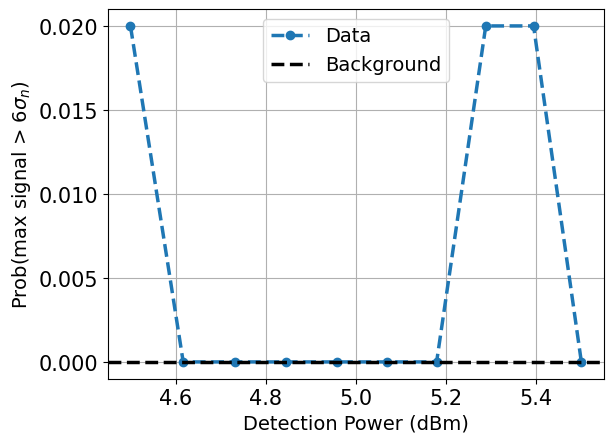

In [41]:
tip_on_files = list_files_in_time_range(data_dir, 
                                        name='RFPowerSweepDifferentialNAcquisitionTipSwitched', start_time='05:30:00', stop_time='20:00:00')

tip_off_files = [
    'data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_22-33-02.h5'
]
plot_Prob_vs_var(tip_on_files, tip_off_files, data_dir=home_dir, var='P_detect', xlabel='Detection Power (dBm)', sigma_cutoff=6
                )

In [40]:
np.sqrt(dBm_to_W(4)/dBm_to_W(5))*176.31

157.13645290236067

In [22]:
import ipywidgets as widgets
from IPython.display import display, clear_output
def plot_peak_timing_across_var(tip_on_files, data_dir, var='t_load', fix_xlim=False):
    """
    Plots histograms of detected power for Tip-On and Tip-Off datasets across a specified variable.

    Parameters:
    - tip_on_files: List of file paths for Tip-On datasets.
    - tip_off_files: List of file paths for Tip-Off datasets.
    - data_dir: Base directory where the data files are located.
    - var: The variable to use for mapping datasets (default is 't_load').
    - fix_xlim: Boolean (default False). If True, the x-axis limits initialize as locked 
                to the global min and max power values across all scanned datasets.
    """

    on_map = {}
    off_map = {}

    # We will track the absolute minimum and maximum power values in nW across all datasets
    global_x_min = float('inf')
    global_x_max = float('-inf')

    print(f"Scanning datasets for {var} and calculating global x-limits...")
    
    # Scan Tip-On files
    for f in tip_on_files:
        try:
            f_data = load_h5_data(f, base=data_dir)
            t_val = f_data.get(f'{var}', None)
            if t_val is not None:
                on_map[t_val] = f
                
            # Convert values to nW to find global limits
            data = f_data.get('all_meas', [])
            if len(data) > 0:
                p_nw_vals = dBm_to_W(np.concatenate(data, axis=0)) * 1e9
                global_x_min = min(global_x_min, np.min(p_nw_vals))
                global_x_max = max(global_x_max, np.max(p_nw_vals))
        except Exception as e:
            print(f"Skipping Tip-On file {f}: {e}")


    unique_t_loads = sorted(list(on_map.keys()))
    print(f"Scan complete. Found {len(unique_t_loads)} valid {var} configurations.")

    # Calculate padding for fixed limits
    has_global_limits = (global_x_min != float('inf') and global_x_max != float('-inf'))
    if has_global_limits:
        x_range = global_x_max - global_x_min
        padding = x_range * 0.05 if x_range > 0 else 1.0
        global_x_min -= padding
        global_x_max += padding
    else:
        global_x_min, global_x_max = 0, 10 # Fallbacks

    # 2. Setup UI elements (Dropdown, Buttons, Checkbox)
    t_load_dropdown = widgets.Dropdown(
        options=unique_t_loads,
        value=unique_t_loads[0] if unique_t_loads else None,
        description=f'{var}:'
    )

    btn_prev = widgets.Button(
        description='Prev',
        button_style='info',     
        icon='arrow-left'        
    )

    btn_next = widgets.Button(
        description='Next',
        button_style='primary',  
        icon='arrow-right'       
    )

    fix_xlim_checkbox = widgets.Checkbox(
        value=fix_xlim,
        description='Fix X-Axis Limits',
        disabled=not has_global_limits,
        indent=False
    )

    plot_output = widgets.Output()

    # 3. Plotting logic wrapped in an output handler
    def draw_plot(change=None):
        t_load = t_load_dropdown.value
        
        with plot_output:
            clear_output(wait=True)
            
            if t_load is None:
                print(f"No {var} configured.")
                return

            on_file_path = on_map.get(t_load)
            off_file_path = off_map.get(t_load) or (list(off_map.values())[0] if off_map else None)

            if not on_file_path:
                print(f"No Tip-On file found for {var}: {t_load}")
                return

            # Load file data
            file = load_h5_data(on_file_path, base=data_dir)
            data = file['all_meas']
            print(np.shape(data))
            
            # Calculate Power in nW for Tip-On
            t_seq_end = file['t_data']
            x_data = t_seq_end * 1e3
            t_axis = np.linspace(0, x_data, len(data[0])) 
            P_nW = np.array([t_axis[np.argmax(data_i)] for data_i in data])
            bin_size = 0.01

            # Plotting Setup
            fig, ax = plt.subplots(figsize=(7, 4))

            # 1. Plot Tip On Histogram
            counts, bin_edges = np.histogram(P_nW, bins=int((max(P_nW) - min(P_nW)) / bin_size))
            ax.bar(
                bin_edges[:-1], 
                counts / np.sum(counts), 
                width=np.diff(bin_edges),
                label='Tip on',
                align='edge', 
                alpha=0.6,
                color='blue'
            )

            # 2. Plot Tip Off Histogram (if background file exists)
            if off_file_path:
                file2 = load_h5_data(off_file_path, base=data_dir)
                data2 = file2['all_meas']
                P_nW_background = dBm_to_W(np.concatenate(data2, axis=0)) * 1e9

                counts_bg, bin_edges_bg = np.histogram(
                    P_nW_background, 
                    bins=int((max(P_nW_background) - min(P_nW_background)) / bin_size)
                )
                ax.bar(
                    bin_edges_bg[:-1], 
                    counts_bg / np.sum(counts_bg), 
                    width=np.diff(bin_edges_bg),
                    label='Tip off',
                    align='edge', 
                    alpha=0.6,
                    color='orange'
                )

            # Apply locked limits if requested
            if fix_xlim_checkbox.value:
                ax.set_xlim(global_x_min, global_x_max)

            # Graph configurations
            ax.set_yscale('log')
            ax.set_title(f"Histogram of Detected Power | {var} = {t_load}")
            ax.set_xlabel('Detected Power (nW)') 
            ax.set_ylabel('Probability Density / 0.01nW bin')
            ax.grid(True)
            ax.legend()
            plt.show()

    # 4. Define event behaviors for Slider/Buttons
    def on_dropdown_change(change):
        draw_plot(change['new'])

    def on_next_clicked(b):
        opts = t_load_dropdown.options
        if not opts: return
        idx = opts.index(t_load_dropdown.value)
        t_load_dropdown.value = opts[idx + 1] if idx < len(opts) - 1 else opts[0]

    def on_prev_clicked(b):
        opts = t_load_dropdown.options
        if not opts: return
        idx = opts.index(t_load_dropdown.value)
        t_load_dropdown.value = opts[idx - 1] if idx > 0 else opts[-1]

    # Link actions to the widgets
    t_load_dropdown.observe(on_dropdown_change, names='value')
    # Automatically redraw when the user switches fixed limits
    fix_xlim_checkbox.observe(lambda change: draw_plot(), names='value')
    
    btn_next.on_click(on_next_clicked)
    btn_prev.on_click(on_prev_clicked)

    # 5. Pack layouts and display
    controls = widgets.HBox([btn_prev, t_load_dropdown, btn_next, fix_xlim_checkbox])
    ui = widgets.VBox([controls, plot_output])

    display(ui)

    # Render the first plot
    if t_load_dropdown.value is not None:
        draw_plot(t_load_dropdown.value)

In [60]:
l = list_files_in_time_range(data_dir, 
                                       name='RFPowerSweepDifferentialNAcquisitionTipSwitched', start_time=None, stop_time=None)
l.sort()
l

['/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_00-34-19.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_01-02-00.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_01-29-44.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_02-03-59.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_02-31-46.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_03-07-32.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_03-35-27.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_04-12-15.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_04-40-21.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferenti

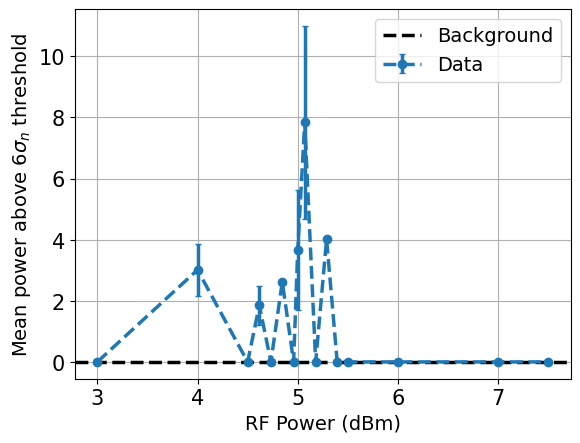

In [62]:
# tip_on_files = list_files_in_time_range(data_dir, 
                                        # name='RFPowerSweepDifferentialNAcquisitionTipSwitched', start_time='05:30:00', stop_time='10:30:00')
tip_on_files = ['/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_21-36-32.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_21-56-47.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_22-15-30.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_22-33-02.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_22-50-11.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_23-36-50.h5',
                '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_00-34-19.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_01-02-00.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_01-29-44.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_02-03-59.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_02-31-46.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_03-07-32.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_03-35-27.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_04-12-15.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_04-40-21.h5',
 '/home/electron/data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_05-08-19.h5']

tip_off_files = [
    'data/experiment_07232026/RFPowerSweepDifferentialNAcquisitionTipSwitched_10-35-24.h5'
]
plot_peak_power_vs_var(tip_on_files, tip_off_files, data_dir=home_dir, var='P_detect', xlabel='RF Power (dBm)', sigma_cutoff=6)

In [23]:
tip_on_files = list_files_in_time_range(data_dir, 
                                        name='RFPowerSweepDifferentialNAcquisitionTipSwitched', start_time=None, stop_time='05:30:00')
plot_peak_timing_across_var(tip_on_files, '', var='P_detect') 

Scanning datasets for P_detect and calculating global x-limits...
Scan complete. Found 10 valid P_detect configurations.
